# Capítulo 21 — Random Forest

En el capítulo dedicado a árboles de decisión vimos que un árbol puede aprender relaciones no lineales y reglas fáciles de recorrer, pero también que puede cambiar bastante ante pequeñas modificaciones en los datos y sobreajustar si crece demasiado.

En este cuaderno construiremos un **Random Forest**: un ensamble que combina muchos árboles diferentes. Observaremos de dónde surge esa diversidad, cómo se agregan las predicciones y por qué el bosque suele ser más estable que un árbol individual.

La práctica principal continuará con **Breast Cancer Wisconsin**, ya conocido en los cuadernos anteriores. La clase positiva será nuevamente el caso maligno. Reservaremos un conjunto de prueba final y usaremos validación cruzada dentro del conjunto de desarrollo para realizar las comparaciones.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- explicar la idea de ensamble;
- reconocer cómo se combinan árboles en clasificación y regresión;
- construir e interpretar una muestra bootstrap;
- comprender la función de bagging y de la selección aleatoria de variables;
- comparar un árbol individual con Random Forest;
- relacionar el ensamble con la reducción de varianza;
- interpretar `n_estimators`, `max_depth`, `min_samples_leaf` y `max_features`;
- reconocer el alcance de la estimación *out-of-bag*;
- analizar importancias de variables con prudencia;
- evaluar el modelo sin usar el test durante la selección.


## 1. Importar las herramientas

Usaremos NumPy y Pandas para organizar los datos, Matplotlib para crear gráficos y `scikit-learn` para entrenar árboles, construir bosques y realizar evaluaciones reproducibles.


In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedShuffleSplit,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.tree import DecisionTreeClassifier

plt.rcParams["figure.dpi"] = 110


## 2. Preparar el problema de clasificación

El dataset contiene mediciones numéricas obtenidas de imágenes digitalizadas de masas mamarias. La variable objetivo original usa `0` para maligno y `1` para benigno. La invertiremos para conservar la convención utilizada en los cuadernos recientes:

- `1`: caso maligno;
- `0`: caso benigno.

> Este conjunto se utiliza con fines didácticos. Un modelo construido aquí no constituye una herramienta clínica.


In [2]:
datos_medicos = load_breast_cancer(as_frame=True)

X = datos_medicos.data.copy()
y = 1 - datos_medicos.target
y.name = "caso_maligno"

pd.DataFrame({
    "filas": [len(X)],
    "variables": [X.shape[1]],
    "casos_benignos": [(y == 0).sum()],
    "casos_malignos": [(y == 1).sum()],
    "proporcion_malignos": [y.mean()],
}).round(3)


,filas,variables,casos_benignos,casos_malignos,proporcion_malignos
0,569,30,357,212,0.373


Todas las variables son numéricas, de modo que podremos concentrarnos en el funcionamiento del bosque. En un dataset con textos o categorías todavía necesitaríamos una transformación adecuada. Que Random Forest no requiera escalado numérico no significa que no necesite preprocesamiento.


## 3. Reservar el conjunto de prueba final

Separaremos el 20% de los casos. Las demostraciones, las comparaciones y las decisiones se realizarán con el conjunto de desarrollo. El test permanecerá reservado hasta la sección final.


In [3]:
X_desarrollo, X_test_final, y_desarrollo, y_test_final = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=21,
        stratify=y,
    )
)

pd.DataFrame({
    "conjunto": ["Desarrollo", "Prueba final"],
    "filas": [len(X_desarrollo), len(X_test_final)],
    "proporcion_malignos": [
        y_desarrollo.mean(),
        y_test_final.mean(),
    ],
}).round(3)


,conjunto,filas,proporcion_malignos
0,Desarrollo,455,0.374
1,Prueba final,114,0.368


Hasta la evaluación definitiva no consultaremos las métricas del test. Si lo usáramos para decidir la cantidad de árboles o modificar otros hiperparámetros, dejaría de ser una prueba independiente.


## 4. Construir una muestra bootstrap

Bagging comienza generando muestras del conjunto de entrenamiento **con reemplazo**. Una fila seleccionada vuelve a quedar disponible: puede aparecer varias veces, mientras otras pueden no aparecer.

Comencemos con cinco etiquetas para ver el mecanismo sin ocultarlo dentro de un modelo.


In [4]:
rng = np.random.default_rng(42)
filas_pequenas = np.array(["A", "B", "C", "D", "E"])

muestras = []
for numero in range(1, 4):
    muestra = rng.choice(
        filas_pequenas,
        size=len(filas_pequenas),
        replace=True,
    )
    muestras.append({
        "muestra": numero,
        "filas_elegidas": " · ".join(muestra),
        "filas_distintas": len(np.unique(muestra)),
    })

pd.DataFrame(muestras)


,muestra,filas_elegidas,filas_distintas
0,1,A · D · D · C · C,3
1,2,E · A · D · B · A,4
2,3,C · E · D · D · D,3


In [5]:
indices_bootstrap = rng.choice(
    len(X_desarrollo),
    size=len(X_desarrollo),
    replace=True,
)

cantidad_unicas = len(np.unique(indices_bootstrap))
cantidad_fuera = len(X_desarrollo) - cantidad_unicas

pd.DataFrame({
    "filas_extraidas": [len(indices_bootstrap)],
    "filas_unicas_dentro": [cantidad_unicas],
    "filas_fuera_de_la_muestra": [cantidad_fuera],
    "proporcion_unica": [
        cantidad_unicas / len(X_desarrollo)
    ],
}).round(3)


,filas_extraidas,filas_unicas_dentro,filas_fuera_de_la_muestra,proporcion_unica
0,455,284,171,0.624


La muestra grande conserva la misma cantidad total de extracciones que el conjunto de desarrollo, pero contiene menos filas únicas. Las restantes son casos *out-of-bag* para ese árbol particular.

Cada árbol recibe una muestra bootstrap distinta. Bagging combina después sus predicciones para reducir la dependencia de una única selección de datos.


## 5. Observar muchos árboles trabajando juntos

Para examinar votos sin tocar el test final, crearemos una división interna del conjunto de desarrollo. Entrenaremos un bosque pequeño y buscaremos en la validación el caso cuya probabilidad quede más cerca de `0,5`.


In [6]:
(
    X_demo_train,
    X_demo_valid,
    y_demo_train,
    y_demo_valid,
) = train_test_split(
    X_desarrollo,
    y_desarrollo,
    test_size=0.25,
    random_state=7,
    stratify=y_desarrollo,
)

bosque_demo = RandomForestClassifier(
    n_estimators=51,
    random_state=42,
    n_jobs=-1,
)
bosque_demo.fit(X_demo_train, y_demo_train)

probabilidades_demo = bosque_demo.predict_proba(
    X_demo_valid
)[:, 1]
posicion_dificil = np.argmin(
    np.abs(probabilidades_demo - 0.5)
)
caso_dificil = X_demo_valid.iloc[[posicion_dificil]]

pd.DataFrame({
    "clase_real": [
        y_demo_valid.iloc[posicion_dificil]
    ],
    "probabilidad_bosque": [
        probabilidades_demo[posicion_dificil]
    ],
    "clase_predicha": [
        bosque_demo.predict(caso_dificil)[0]
    ],
}).round(3)


,clase_real,probabilidad_bosque,clase_predicha
0,1,0.529,1


In [7]:
votos = np.array([
    arbol.predict(caso_dificil.to_numpy())[0]
    for arbol in bosque_demo.estimators_
])
probabilidades_arboles = np.array([
    arbol.predict_proba(
        caso_dificil.to_numpy()
    )[0, 1]
    for arbol in bosque_demo.estimators_
])

resumen_votos = pd.DataFrame({
    "cantidad_arboles": [len(votos)],
    "votos_benigno": [(votos == 0).sum()],
    "votos_maligno": [(votos == 1).sum()],
    "promedio_probabilidad_maligno": [
        probabilidades_arboles.mean()
    ],
    "prediccion_bosque": [
        bosque_demo.predict(caso_dificil)[0]
    ],
})

pd.DataFrame({
    "arbol": np.arange(1, 13),
    "voto": votos[:12],
})


,arbol,voto
0,1,1.0
1,2,0.0
2,3,0.0
3,4,0.0
4,5,1.0
5,6,1.0
6,7,1.0
7,8,0.0
8,9,1.0
9,10,1.0


In [8]:
resumen_votos.round(3)


,cantidad_arboles,votos_benigno,votos_maligno,promedio_probabilidad_maligno,prediccion_bosque
0,51,24,27,0.529,1


La votación es una intuición útil: varios árboles pueden discrepar y la combinación evita depender de uno solo. Técnicamente, `RandomForestClassifier` de `scikit-learn` promedia las probabilidades estimadas por los árboles y elige la clase con mayor promedio. En este caso, el resultado coincide con la clase que reúne más votos.


### ¿Qué ocurre en regresión?

En regresión, cada árbol produce un valor numérico y el bosque calcula su promedio. Usaremos un ejemplo pequeño de viviendas solo para comprobar esa agregación.


In [9]:
rng_reg = np.random.default_rng(8)
superficie = rng_reg.uniform(40, 150, 45)
antiguedad = rng_reg.uniform(0, 45, 45)

X_viviendas = pd.DataFrame({
    "superficie_m2": superficie,
    "antiguedad_anios": antiguedad,
})
y_precios = (
    35_000
    + 1_150 * superficie
    - 750 * antiguedad
    + rng_reg.normal(0, 8_000, 45)
)

bosque_reg = RandomForestRegressor(
    n_estimators=9,
    random_state=42,
)
bosque_reg.fit(X_viviendas, y_precios)

vivienda_nueva = pd.DataFrame({
    "superficie_m2": [92],
    "antiguedad_anios": [12],
})
predicciones_arboles = np.array([
    arbol.predict(vivienda_nueva.to_numpy())[0]
    for arbol in bosque_reg.estimators_
])

pd.DataFrame({
    "predicciones_individuales": [
        np.round(predicciones_arboles, 2).tolist()
    ],
    "promedio_manual": [
        predicciones_arboles.mean()
    ],
    "prediccion_bosque": [
        bosque_reg.predict(vivienda_nueva)[0]
    ],
}).round(2)


,predicciones_individuales,promedio_manual,prediccion_bosque
0,"[128466.71, 128466.71, 128466.71, 131107.0, 13...",129052.97,129052.97


El promedio manual coincide con `predict()`. Las predicciones individuales no tienen que ser perfectas ni iguales: el ensamble aprovecha precisamente su diversidad.


## 6. Diversidad de filas y variables

Random Forest agrega una segunda fuente de aleatoriedad al bootstrap: en cada división, un árbol considera solo una parte de las variables disponibles. `max_features` controla cuántas pueden competir en cada pregunta.

No todos los árboles comienzan con la misma variable. Podemos revisar la pregunta raíz de los 51 árboles del bosque de demostración.


In [10]:
variables_raiz = []

for arbol in bosque_demo.estimators_:
    indice_variable = arbol.tree_.feature[0]
    variables_raiz.append(
        X_demo_train.columns[indice_variable]
    )

frecuencias_raiz = (
    pd.Series(variables_raiz, name="variable")
    .value_counts()
    .rename_axis("variable_raiz")
    .reset_index(name="cantidad_arboles")
)

pd.DataFrame({
    "variables_totales": [X_demo_train.shape[1]],
    "variables_consideradas_por_split": [
        bosque_demo.estimators_[0].max_features_
    ],
    "variables_distintas_en_la_raiz": [
        frecuencias_raiz.shape[0]
    ],
})


,variables_totales,variables_consideradas_por_split,variables_distintas_en_la_raiz
0,30,5,16


In [11]:
frecuencias_raiz.head(10)


,variable_raiz,cantidad_arboles
0,worst concave points,7
1,mean concavity,6
2,worst radius,5
3,worst concavity,4
4,mean perimeter,4
5,worst perimeter,4
6,mean concave points,4
7,area error,3
8,worst area,3
9,mean radius,3


El valor observado de `max_features_` no indica que el árbol use solo esas variables en total. Indica cuántas candidatas evalúa en **cada división**. En la pregunta siguiente puede recibir otro subconjunto.

La diversidad surge entonces de dos mecanismos:

1. cada árbol recibe una muestra bootstrap diferente de filas;
2. cada división considera un subconjunto aleatorio de variables.

Si todos los árboles fueran idénticos, combinar sus respuestas aportaría muy poco.


## 7. Comparar un árbol con un bosque

Usaremos exactamente los mismos cinco folds para ambos modelos. Mediremos F1 porque la clase positiva es el caso maligno y queremos considerar conjuntamente falsas alarmas y casos no detectados. También conservaremos accuracy como referencia.


In [12]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

modelos = {
    "Árbol individual": DecisionTreeClassifier(
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    ),
}

resultados_cv = {}

for nombre, modelo in modelos.items():
    resultados_cv[nombre] = cross_validate(
        modelo,
        X_desarrollo,
        y_desarrollo,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1": "f1",
        },
        return_train_score=True,
    )


In [13]:
filas_comparacion = []

for nombre, resultados in resultados_cv.items():
    filas_comparacion.append({
        "modelo": nombre,
        "F1_entrenamiento": (
            resultados["train_f1"].mean()
        ),
        "F1_validacion": (
            resultados["test_f1"].mean()
        ),
        "desviacion_F1": (
            resultados["test_f1"].std()
        ),
        "accuracy_validacion": (
            resultados["test_accuracy"].mean()
        ),
    })

comparacion_modelos = pd.DataFrame(
    filas_comparacion
)
comparacion_modelos.round(4)


,modelo,F1_entrenamiento,F1_validacion,desviacion_F1,accuracy_validacion
0,Árbol individual,1.0,0.8869,0.0571,0.9187
1,Random Forest,1.0,0.9440,0.0422,0.9582


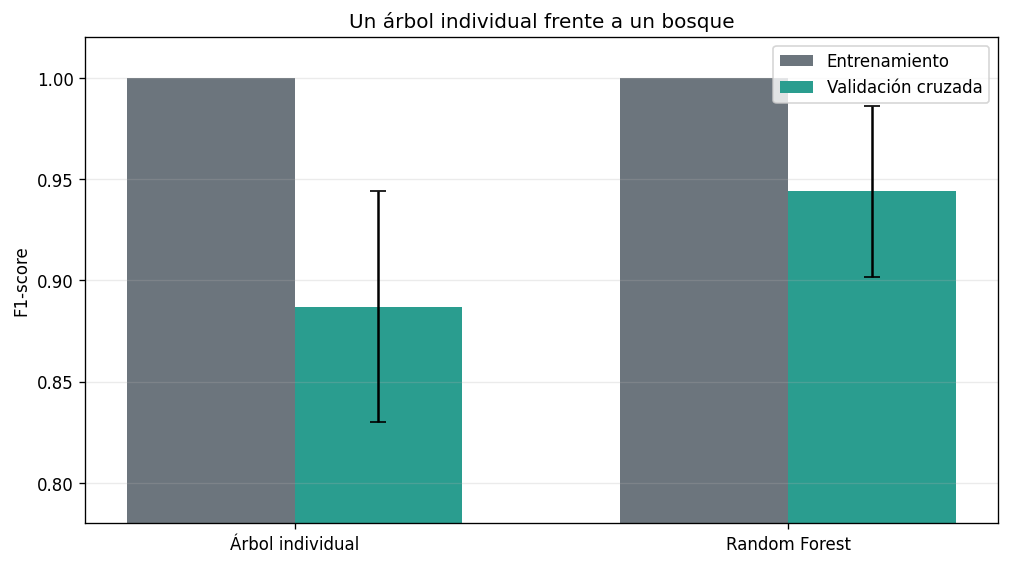

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))

x = np.arange(len(comparacion_modelos))
ancho = 0.34

ax.bar(
    x - ancho / 2,
    comparacion_modelos["F1_entrenamiento"],
    width=ancho,
    color="#6C757D",
    label="Entrenamiento",
)
ax.bar(
    x + ancho / 2,
    comparacion_modelos["F1_validacion"],
    width=ancho,
    yerr=comparacion_modelos["desviacion_F1"],
    capsize=5,
    color="#2A9D8F",
    label="Validación cruzada",
)

ax.set_xticks(x)
ax.set_xticklabels(comparacion_modelos["modelo"])
ax.set_ylim(0.78, 1.02)
ax.set_ylabel("F1-score")
ax.set_title("Un árbol individual frente a un bosque")
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


Ambos modelos alcanzan F1 `1,000` en entrenamiento. Sin embargo, el árbol individual baja a un promedio de `0,887` en validación, mientras que Random Forest alcanza `0,944`. La desviación entre folds también disminuye de `0,057` a `0,042`.

Esta comparación no prueba que el bosque siempre sea superior. Muestra, con las mismas divisiones, el patrón que motiva al ensamble: conservar la flexibilidad de los árboles y reducir la dependencia de uno solo.


## 8. Medir la estabilidad ante divisiones diferentes

La varianza de un árbol también puede observarse cambiando ligeramente las filas usadas para entrenar y validar. Repetiremos quince separaciones estratificadas dentro del conjunto de desarrollo y compararemos la distribución del F1.


In [15]:
divisiones_repetidas = StratifiedShuffleSplit(
    n_splits=15,
    test_size=0.25,
    random_state=42,
)

puntajes_repetidos = {}

for nombre, modelo in modelos.items():
    puntajes_repetidos[nombre] = cross_val_score(
        modelo,
        X_desarrollo,
        y_desarrollo,
        cv=divisiones_repetidas,
        scoring="f1",
    )

pd.DataFrame({
    nombre: [
        valores.mean(),
        valores.std(),
        valores.min(),
        valores.max(),
    ]
    for nombre, valores in puntajes_repetidos.items()
}, index=[
    "promedio",
    "desviacion",
    "minimo",
    "maximo",
]).round(4)


,Árbol individual,Random Forest
promedio,0.8983,0.9390
desviacion,0.0334,0.0258
minimo,0.8409,0.8916
maximo,0.9524,0.9773


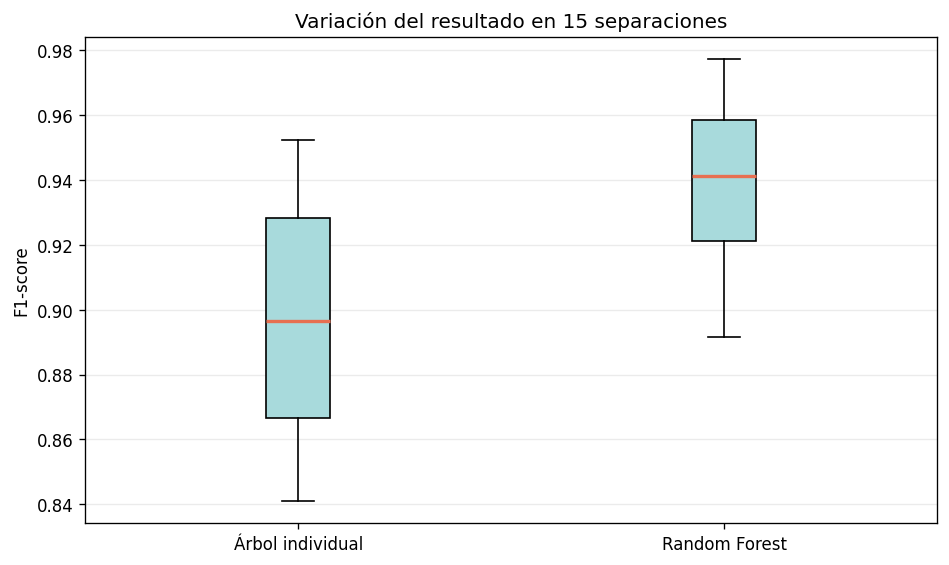

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.8))

ax.boxplot(
    [
        puntajes_repetidos["Árbol individual"],
        puntajes_repetidos["Random Forest"],
    ],
    tick_labels=[
        "Árbol individual",
        "Random Forest",
    ],
    patch_artist=True,
    boxprops={"facecolor": "#A8DADC"},
    medianprops={
        "color": "#E76F51",
        "linewidth": 2,
    },
)

ax.set_ylabel("F1-score")
ax.set_title(
    "Variación del resultado en 15 separaciones"
)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


El bosque no produce el mismo valor en todas las divisiones, pero su distribución es más alta y menos dispersa. Su F1 promedio es `0,939`, frente a `0,898` para el árbol, y su desviación baja de `0,033` a `0,026`. Esa menor sensibilidad a una muestra particular es la reducción de varianza que buscamos con bagging.


## 9. ¿Cuántos árboles necesita el bosque?

`n_estimators` indica la cantidad de árboles. Con muy pocos árboles, el resultado puede depender demasiado de votos particulares. Al agregar árboles, el ensamble suele estabilizarse, aunque el costo computacional continúa creciendo.

Mediremos el F1 promedio y el tiempo de ajuste dentro de la misma validación cruzada.


In [17]:
cantidades_arboles = [1, 5, 10, 25, 50, 100, 200]
filas_estimadores = []

for cantidad in cantidades_arboles:
    modelo = RandomForestClassifier(
        n_estimators=cantidad,
        random_state=42,
        n_jobs=-1,
    )
    resultados = cross_validate(
        modelo,
        X_desarrollo,
        y_desarrollo,
        cv=cv,
        scoring="f1",
    )
    filas_estimadores.append({
        "n_estimators": cantidad,
        "F1_promedio": (
            resultados["test_score"].mean()
        ),
        "desviacion_F1": (
            resultados["test_score"].std()
        ),
        "tiempo_ajuste_promedio": (
            resultados["fit_time"].mean()
        ),
    })

resultados_estimadores = pd.DataFrame(
    filas_estimadores
)


In [18]:
resultados_estimadores.round(4)


,n_estimators,F1_promedio,desviacion_F1,tiempo_ajuste_promedio
0,1,0.8988,0.0401,0.0141
1,5,0.9227,0.0490,0.0145
2,10,0.9258,0.0461,0.0269
3,25,0.9329,0.0478,0.0391
4,50,0.9414,0.0446,0.0729
5,100,0.9440,0.0422,0.1483
6,200,0.9440,0.0422,0.2709


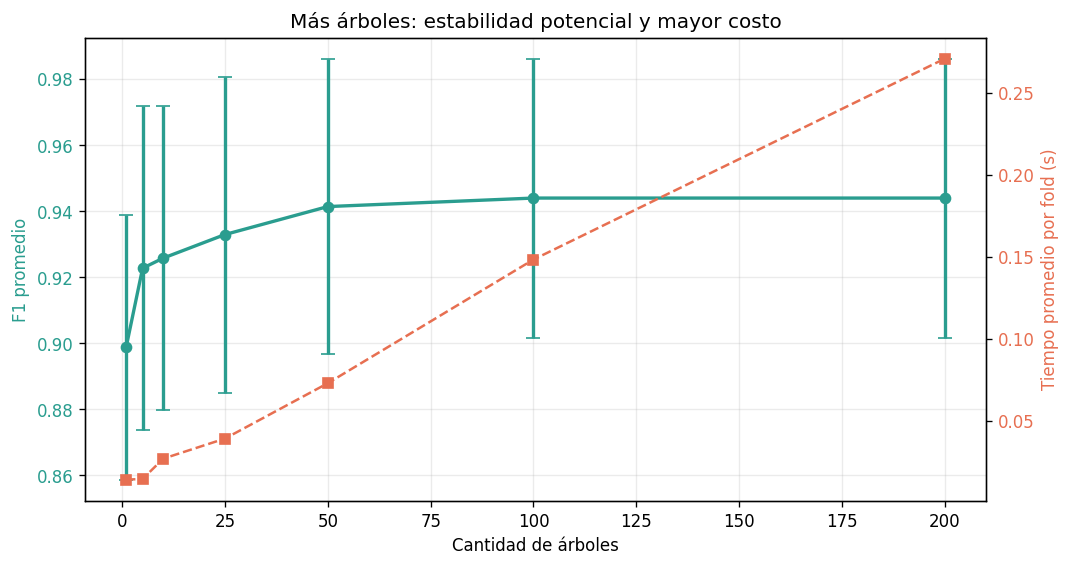

In [19]:
fig, ax_f1 = plt.subplots(figsize=(9, 4.8))

ax_f1.errorbar(
    resultados_estimadores["n_estimators"],
    resultados_estimadores["F1_promedio"],
    yerr=resultados_estimadores["desviacion_F1"],
    marker="o",
    linewidth=2,
    capsize=4,
    color="#2A9D8F",
    label="F1 promedio",
)
ax_f1.set_xlabel("Cantidad de árboles")
ax_f1.set_ylabel("F1 promedio", color="#2A9D8F")
ax_f1.tick_params(axis="y", labelcolor="#2A9D8F")
ax_f1.grid(alpha=0.25)

ax_tiempo = ax_f1.twinx()
ax_tiempo.plot(
    resultados_estimadores["n_estimators"],
    resultados_estimadores["tiempo_ajuste_promedio"],
    marker="s",
    linestyle="--",
    color="#E76F51",
    label="Tiempo de ajuste",
)
ax_tiempo.set_ylabel(
    "Tiempo promedio por fold (s)",
    color="#E76F51",
)
ax_tiempo.tick_params(
    axis="y",
    labelcolor="#E76F51",
)

ax_f1.set_title(
    "Más árboles: estabilidad potencial y mayor costo"
)
plt.tight_layout()
plt.show()


La mejora no es continua: el F1 promedio pasa de `0,899` con un árbol a `0,944` con cien, pero permanece en `0,944` al llegar a doscientos. El tiempo, en cambio, sigue aumentando. `n_estimators` controla principalmente la estabilidad y el costo; no vuelve ilimitadamente mejor al modelo.


## 10. Controlar la flexibilidad y la diversidad

Otros hiperparámetros actúan sobre cada árbol:

- `max_depth` limita su profundidad;
- `min_samples_leaf` evita hojas con muy pocos casos;
- `max_features` regula cuántas variables pueden competir en cada división.

Compararemos algunas configuraciones ilustrativas. No se trata de una búsqueda exhaustiva ni usaremos el test para elegir.


In [20]:
configuraciones = {
    "Flexible": {
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
    },
    "Profundidad 5": {
        "max_depth": 5,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
    },
    "Hojas de 5 casos": {
        "max_depth": None,
        "min_samples_leaf": 5,
        "max_features": "sqrt",
    },
    "Todas las variables": {
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": 1.0,
    },
}

filas_configuraciones = []

for nombre, parametros in configuraciones.items():
    modelo = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        **parametros,
    )
    resultados = cross_validate(
        modelo,
        X_desarrollo,
        y_desarrollo,
        cv=cv,
        scoring="f1",
        return_train_score=True,
    )
    filas_configuraciones.append({
        "configuracion": nombre,
        "F1_entrenamiento": (
            resultados["train_score"].mean()
        ),
        "F1_validacion": (
            resultados["test_score"].mean()
        ),
        "desviacion_F1": (
            resultados["test_score"].std()
        ),
    })

comparacion_configuraciones = pd.DataFrame(
    filas_configuraciones
)
comparacion_configuraciones.round(4)


,configuracion,F1_entrenamiento,F1_validacion,desviacion_F1
0,Flexible,1.0000,0.9440,0.0422
1,Profundidad 5,0.9903,0.9440,0.0422
2,Hojas de 5 casos,0.9747,0.9407,0.0419
3,Todas las variables,1.0000,0.9430,0.0291


Las configuraciones producen resultados cercanos. El bosque flexible y el limitado a profundidad 5 empatan con un F1 promedio de `0,944`; exigir hojas de cinco casos lo reduce levemente a `0,941`. Permitir todas las variables en cada división obtiene `0,943` y disminuye una fuente de diversidad.

Una diferencia pequeña en un único experimento no justifica conclusiones universales. En un proyecto real, estos hiperparámetros se elegirían con un procedimiento reproducible como el trabajado en el Capítulo 19.


## 11. Obtener una estimación out-of-bag

Como cada árbol deja algunas filas fuera de su muestra bootstrap, esas filas pueden actuar como pequeños casos de validación para ese árbol. Con `oob_score=True`, el bosque reúne esas predicciones y calcula una estimación adicional.

`oob_score_` usa accuracy por defecto. La compararemos con la accuracy promedio de validación cruzada, siempre dentro del conjunto de desarrollo.


In [21]:
modelo_oob = RandomForestClassifier(
    n_estimators=300,
    oob_score=True,
    random_state=42,
    n_jobs=-1,
)
modelo_oob.fit(X_desarrollo, y_desarrollo)

accuracy_cv = cross_val_score(
    RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
    ),
    X_desarrollo,
    y_desarrollo,
    cv=cv,
    scoring="accuracy",
)

pd.DataFrame({
    "estimacion": [
        "Out-of-bag",
        "Validación cruzada",
    ],
    "accuracy": [
        modelo_oob.oob_score_,
        accuracy_cv.mean(),
    ],
    "desviacion_entre_folds": [
        np.nan,
        accuracy_cv.std(),
    ],
}).round(4)


,estimacion,accuracy,desviacion_entre_folds
0,Out-of-bag,0.9516,NaN
1,Validación cruzada,0.9582,0.0322


Los valores son parecidos sin ser idénticos: la estimación out-of-bag obtiene accuracy `0,952` y la validación cruzada, `0,958`. Se construyen de manera diferente. La estimación out-of-bag es útil y económica cuando usamos bootstrap, pero no convierte al test final en innecesario ni reemplaza automáticamente un diseño temporal o por grupos.


## 12. Evaluar una vez sobre el test final

Conservaremos como modelo final la configuración flexible de 200 árboles usada en la comparación principal. Esta elección es didáctica: obtuvo un resultado de validación sólido sin requerir una búsqueda adicional.


In [22]:
modelo_final = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)
modelo_final.fit(X_desarrollo, y_desarrollo)

pred_test = modelo_final.predict(X_test_final)

metricas_finales = pd.DataFrame({
    "accuracy": [
        accuracy_score(y_test_final, pred_test)
    ],
    "precision": [
        precision_score(y_test_final, pred_test)
    ],
    "recall": [
        recall_score(y_test_final, pred_test)
    ],
    "F1": [
        f1_score(y_test_final, pred_test)
    ],
})

matriz_final = pd.DataFrame(
    confusion_matrix(y_test_final, pred_test),
    index=["Real benigno", "Real maligno"],
    columns=["Predicho benigno", "Predicho maligno"],
)

metricas_finales.round(4)


,accuracy,precision,recall,F1
0,0.9649,0.975,0.9286,0.9512


In [23]:
matriz_final


,Predicho benigno,Predicho maligno
Real benigno,71,1
Real maligno,3,39


El bosque obtiene F1 `0,951` y accuracy `0,965` en el test final. La matriz muestra 71 casos benignos y 39 malignos correctamente clasificados, una falsa alarma y tres casos malignos no detectados. Una sola cifra no muestra qué errores cometió el modelo ni cuál sería su costo en el contexto real.

Tampoco debemos convertir esta evaluación didáctica en una afirmación clínica: el dataset es pequeño, histórico y simplificado respecto de un sistema de diagnóstico real.


## 13. Analizar la importancia de variables

Random Forest ofrece `feature_importances_`, una medida basada en cuánto contribuyeron las variables a reducir la impureza en los árboles. La complementaremos con **permutation importance**, que mide cuánto cae el F1 cuando desordenamos una columna y rompemos su información.

Usaremos el test únicamente ahora, después de haber cerrado la evaluación. Este análisis es posterior al entrenamiento; no modificaremos el modelo en función del resultado.


In [24]:
importancia_interna = pd.Series(
    modelo_final.feature_importances_,
    index=X.columns,
    name="importancia_interna",
).sort_values(ascending=False)

resultado_permutacion = permutation_importance(
    modelo_final,
    X_test_final,
    y_test_final,
    scoring="f1",
    n_repeats=15,
    random_state=42,
    n_jobs=-1,
)

importancia_permutacion = pd.Series(
    resultado_permutacion.importances_mean,
    index=X.columns,
    name="caida_F1_por_permutacion",
).sort_values(ascending=False)

top_interna_tabla = importancia_interna.head(10)
top_permutacion_tabla = importancia_permutacion.head(10)

pd.DataFrame({
    "variable_importancia_interna": (
        top_interna_tabla.index
    ),
    "importancia_interna": (
        top_interna_tabla.values
    ),
    "variable_permutacion": (
        top_permutacion_tabla.index
    ),
    "caida_F1_por_permutacion": (
        top_permutacion_tabla.values
    ),
}).round(4)


,variable_importancia_interna,importancia_interna,variable_permutacion,caida_F1_por_permutacion
0,worst area,0.1339,worst area,0.0212
1,worst concave points,0.1310,worst radius,0.0113
2,worst perimeter,0.1178,worst perimeter,0.0079
3,mean concave points,0.1029,perimeter error,0.0000
4,worst radius,0.0748,mean smoothness,0.0000
5,mean concavity,0.0529,mean compactness,0.0000
6,mean perimeter,0.0518,compactness error,0.0000
7,mean area,0.0451,mean fractal dimension,0.0000
8,mean radius,0.0431,fractal dimension error,0.0000
9,worst concavity,0.0367,worst smoothness,-0.0008


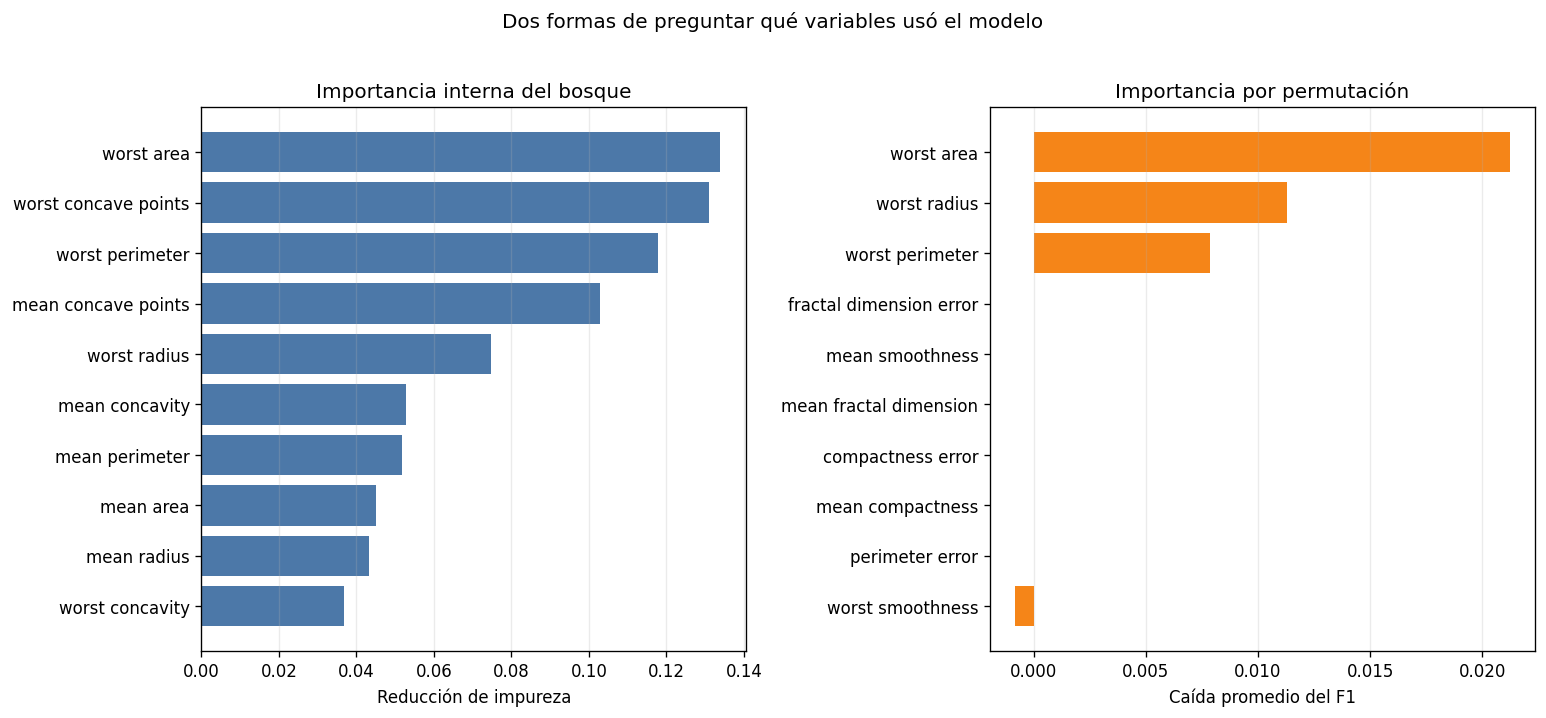

In [25]:
top_interna = importancia_interna.head(10).sort_values()
top_permutacion = (
    importancia_permutacion.head(10).sort_values()
)

fig, ejes = plt.subplots(
    1,
    2,
    figsize=(13, 5.8),
)

ejes[0].barh(
    top_interna.index,
    top_interna.values,
    color="#4C78A8",
)
ejes[0].set_title(
    "Importancia interna del bosque"
)
ejes[0].set_xlabel("Reducción de impureza")

ejes[1].barh(
    top_permutacion.index,
    top_permutacion.values,
    color="#F58518",
)
ejes[1].set_title(
    "Importancia por permutación"
)
ejes[1].set_xlabel("Caída promedio del F1")

for ax in ejes:
    ax.grid(axis="x", alpha=0.25)

fig.suptitle(
    "Dos formas de preguntar qué variables usó el modelo",
    y=1.02,
)
plt.tight_layout()
plt.show()


Los rankings no son idénticos porque responden preguntas distintas. Además, muchas mediciones del dataset están correlacionadas: radio, perímetro y área contienen información parcialmente repetida. El bosque puede repartir la importancia entre ellas o sustituir una por otra.

Una importancia alta significa que la variable fue útil para este modelo. No demuestra causalidad, validez clínica ni disponibilidad en un futuro sistema. Una columna con fuga de datos también podría aparecer como extremadamente importante.


## 14. Comprobar que el bosque no necesita escalado

Los árboles comparan valores con umbrales; no calculan distancias entre observaciones. Multiplicaremos una variable por mil en desarrollo y test, entrenaremos el mismo bosque y compararemos sus predicciones.


In [26]:
X_desarrollo_reescalado = X_desarrollo.copy()
X_test_reescalado = X_test_final.copy()

X_desarrollo_reescalado["mean area"] *= 1_000
X_test_reescalado["mean area"] *= 1_000

modelo_reescalado = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)
modelo_reescalado.fit(
    X_desarrollo_reescalado,
    y_desarrollo,
)
pred_reescaladas = modelo_reescalado.predict(
    X_test_reescalado
)

pd.DataFrame({
    "proporcion_predicciones_iguales": [
        np.mean(pred_test == pred_reescaladas)
    ],
    "F1_original": [
        f1_score(y_test_final, pred_test)
    ],
    "F1_con_variable_reescalada": [
        f1_score(
            y_test_final,
            pred_reescaladas,
        )
    ],
}).round(4)


,proporcion_predicciones_iguales,F1_original,F1_con_variable_reescalada
0,1.0,0.9512,0.9512


El cambio de unidades modifica los umbrales numéricos aprendidos, pero conserva el orden de los valores. Por eso las decisiones del bosque se mantienen. Esta propiedad no elimina la necesidad de imputar faltantes, codificar categorías o evitar fuga de datos.


## 15. Actividad breve

La siguiente celda compara seis combinaciones sin consultar nuevamente el test final. Podés modificar las listas para explorar otras cantidades de árboles y otros valores de `max_features`.


In [27]:
valores_n = [25, 100, 250]
valores_max_features = ["sqrt", 0.5]

cv_actividad = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=11,
)
filas_actividad = []

for cantidad in valores_n:
    for max_features in valores_max_features:
        inicio = time.perf_counter()
        puntajes = cross_val_score(
            RandomForestClassifier(
                n_estimators=cantidad,
                max_features=max_features,
                random_state=42,
                n_jobs=-1,
            ),
            X_desarrollo,
            y_desarrollo,
            cv=cv_actividad,
            scoring="f1",
        )
        duracion = time.perf_counter() - inicio

        filas_actividad.append({
            "n_estimators": cantidad,
            "max_features": str(max_features),
            "F1_promedio": puntajes.mean(),
            "desviacion_F1": puntajes.std(),
            "tiempo_total_s": duracion,
        })

pd.DataFrame(filas_actividad).round(4)


,n_estimators,max_features,F1_promedio,desviacion_F1,tiempo_total_s
0,25,sqrt,0.9425,0.0188,0.1744
1,25,0.5,0.9470,0.0076,0.1876
2,100,sqrt,0.9433,0.0030,0.5738
3,100,0.5,0.9554,0.0077,0.6074
4,250,sqrt,0.9467,0.0074,1.3083
5,250,0.5,0.9527,0.0031,1.3488


Podés continuar la actividad de estas maneras:

- agregá `10` y `500` a `valores_n`;
- probá `max_features=1.0`;
- incorporá `min_samples_leaf=5`;
- compará promedio, variabilidad y costo;
- explicá si una diferencia pequeña justificaría el tiempo adicional.

No vuelvas a usar el test para decidir. La actividad debe resolverse con validación sobre el conjunto de desarrollo.


## 16. Ventajas y limitaciones

Random Forest suele ofrecer un desempeño sólido en datos tabulares. Captura relaciones no lineales e interacciones, reduce la inestabilidad de un árbol individual y no requiere escalado numérico. Puede utilizarse tanto para clasificación como para regresión.

El costo de esa potencia es una menor interpretabilidad directa. Un árbol pequeño puede recorrerse como una secuencia de preguntas; un bosque con cientos de árboles debe analizarse de manera agregada. También requiere más tiempo y memoria, puede aprender fuga de datos con gran eficacia y, en regresión, no es una buena herramienta para extrapolar fuera de los patrones observados.

Si un modelo más simple obtiene un resultado parecido y la explicación es importante, la alternativa simple puede seguir siendo preferible.


## 17. Síntesis

En este cuaderno:

- construimos muestras bootstrap con reemplazo;
- observamos filas repetidas y casos out-of-bag;
- comprobamos la votación en clasificación y el promedio en regresión;
- reconocimos la selección aleatoria de variables;
- comparamos un árbol individual con Random Forest usando los mismos folds;
- observamos una menor variabilidad ante distintas divisiones;
- estudiamos el efecto de la cantidad de árboles y otros hiperparámetros;
- obtuvimos una estimación out-of-bag;
- realizamos una única evaluación final sobre test;
- contrastamos dos medidas de importancia de variables;
- verificamos que el escalado numérico no cambia las predicciones del bosque.

Random Forest no vuelve perfectos a sus árboles. Su fortaleza está en combinar muchos árboles diversos para que la predicción final dependa menos de los errores particulares de cada uno.


## Para pensar

1. ¿Por qué entrenar cien veces exactamente el mismo árbol no produciría un ensamble útil?
2. ¿Qué función cumplen el muestreo bootstrap y `max_features` en la diversidad del bosque?
3. ¿Por qué agregar árboles puede estabilizar el resultado sin reducir indefinidamente el error?
4. ¿Qué diferencia hay entre afirmar que una variable fue importante para el modelo y afirmar que causa el resultado?
5. Si Random Forest y un modelo más simple obtuvieran resultados casi iguales, ¿qué otros criterios usarías para elegir?


---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
